In [2]:
import pandas as pd

# Membaca dataset realestate (CSV format Indonesia)
df = pd.read_csv('data_real_estate.csv', sep=';')

# Menampilkan informasi struktur kolom dan tipe data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_Properti        85 non-null     str    
 1   Luas_Tanah_m2      74 non-null     float64
 2   Luas_Bangunan_m2   85 non-null     int64  
 3   Kota_Lokasi        85 non-null     str    
 4   Harga_Jual_Rupiah  85 non-null     int64  
 5   Jumlah_Kamar       85 non-null     int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 5.3 KB


=== RINGKASAN STATISTIK DESKRIPTIF ===
       Luas_Tanah_m2  Luas_Bangunan_m2  Harga_Jual_Rupiah  Jumlah_Kamar
count      74.000000         85.000000       8.500000e+01     85.000000
mean      128.972973        144.800000       2.392797e+09      3.129412
std        63.441262         58.511863       4.071908e+09      1.307380
min        60.000000         38.000000       3.520055e+08      1.000000
25%        72.000000        104.000000       8.463188e+08      2.000000
50%       120.000000        142.000000       1.654662e+09      3.000000
75%       150.000000        193.000000       2.284047e+09      4.000000
max       300.000000        248.000000       3.183512e+10      5.000000

Nilai Mean (Rata-rata): Rp 2,392,796,786.80
Nilai Median (Nilai Tengah): Rp 1,654,662,280.00


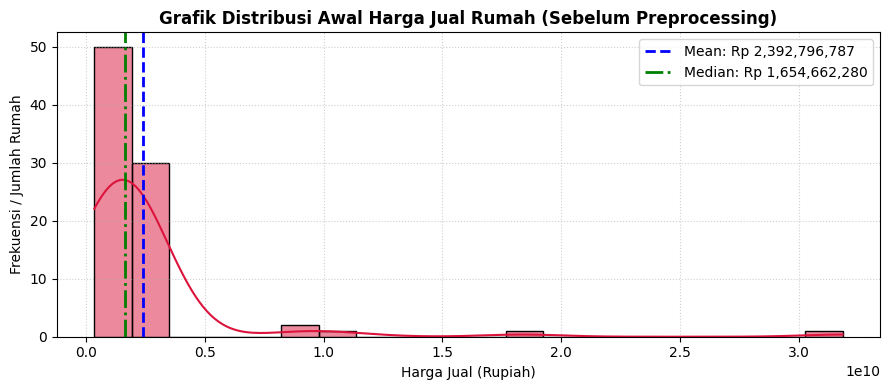

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menampilkan ringkasan statistik deskriptif awal (.describe)
print("=== RINGKASAN STATISTIK DESKRIPTIF ===")
print(df[['Luas_Tanah_m2', 'Luas_Bangunan_m2', 'Harga_Jual_Rupiah', 'Jumlah_Kamar']].describe())

# 2. Menghitung Nilai Mean dan Median khusus kolom Harga Jual
mean_harga = df['Harga_Jual_Rupiah'].mean()
median_harga = df['Harga_Jual_Rupiah'].median()

print(f"\nNilai Mean (Rata-rata): Rp {mean_harga:,.2f}")
print(f"Nilai Median (Nilai Tengah): Rp {median_harga:,.2f}")

# 3. Membuat Grafik Distribusi Awal (Histogram) Sebelum Dibersihkan
plt.figure(figsize=(9, 4))
sns.histplot(df['Harga_Jual_Rupiah'].dropna(), kde=True, color='crimson', bins=20)
plt.axvline(mean_harga, color='blue', linestyle='--', linewidth=2, label=f'Mean: Rp {mean_harga:,.0f}')
plt.axvline(median_harga, color='green', linestyle='-.', linewidth=2, label=f'Median: Rp {median_harga:,.0f}')

plt.title("Grafik Distribusi Awal Harga Jual Rumah (Sebelum Preprocessing)", fontsize=12, fontweight='bold')
plt.xlabel("Harga Jual (Rupiah)")
plt.ylabel("Frekuensi / Jumlah Rumah")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



--- MEMULAI PROSES PREPROCESSING & TRANSFORMASI ---

Ukuran Data SEBELUM dibersihkan : 85 baris
Ukuran Data SESUDAH dibersihkan: 80 baris
Batas atas harga wajar (tanpa outlier): Rp 4,440,639,247.50

--- CONTOH DATA SEBELUM DI BERSIHKAN (BEFORE) ---


,ID_Properti,Luas_Tanah_m2,Harga_Jual_Rupiah
0,PROP-001,90.0,"Rp 1,114,733,175.00"
1,PROP-002,72.0,"Rp 2,599,139,494.00"
2,PROP-003,120.0,"Rp 2,958,362,244.00"
3,PROP-004,NaN,"Rp 18,364,274,880.00"
4,PROP-005,200.0,"Rp 1,689,423,628.00"
5,PROP-006,NaN,"Rp 352,058,324.00"
6,PROP-007,90.0,"Rp 1,335,952,369.00"
7,PROP-008,72.0,"Rp 1,154,081,204.00"




--- CONTOH DATA SESUDAH DI BERSIHKAN (AFTER) ---


,ID_Properti,Luas_Tanah_m2,Harga_Jual_Rupiah,Harga_per_Meter
0,PROP-001,90.0,"Rp 1,114,733,175.00","Rp 12,385,924.17"
1,PROP-002,72.0,"Rp 2,599,139,494.00","Rp 36,099,159.64"
2,PROP-003,120.0,"Rp 2,958,362,244.00","Rp 24,653,018.70"
4,PROP-005,200.0,"Rp 1,689,423,628.00","Rp 8,447,118.14"
5,PROP-006,120.0,"Rp 352,058,324.00","Rp 2,933,819.37"
6,PROP-007,90.0,"Rp 1,335,952,369.00","Rp 14,843,915.21"
7,PROP-008,72.0,"Rp 1,154,081,204.00","Rp 16,028,905.61"
8,PROP-009,120.0,"Rp 577,526,500.00","Rp 4,812,720.83"




--- GENERATING GRAFIK AGREGASI UNTUK SLIDE 3 ---


C:\Users\herip\AppData\Local\Temp\ipykernel_13464\4182571757.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


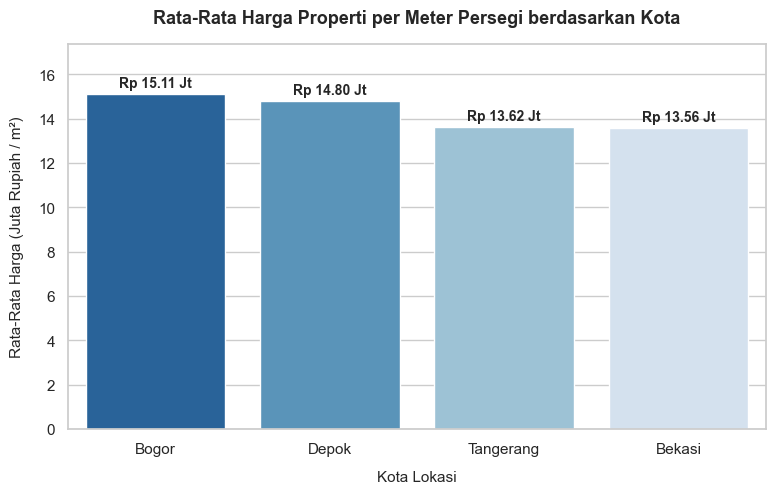


--- PROSES SELESAI: File 'grafik_harga_per_meter.png' berhasil disimpan! ---


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("--- MEMULAI PROSES PREPROCESSING & TRANSFORMASI ---\n")

# =====================================================================
# # 1. MENGHITUNG BATAS OUTLIER DENGAN METODE IQR
# =====================================================================
Q1 = df["Harga_Jual_Rupiah"].quantile(0.25)
Q3 = df["Harga_Jual_Rupiah"].quantile(0.75)
IQR = Q3 - Q1

# Rumus batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR


# =====================================================================
# # 2. PROSES PEMBERSIHAN OUTLIER
# =====================================================================
# Hanya mengambil data yang berada di dalam ambang batas wajar (menghapus 5 outlier)
df_clean = df[
    (df["Harga_Jual_Rupiah"] >= batas_bawah)
    & (df["Harga_Jual_Rupiah"] <= batas_atas)
].copy()


# =====================================================================
# # 3. HANDLING MISSING VALUES (Imputasi Luas Tanah dengan nilai Median)
# =====================================================================
median_luas_tanah = df_clean["Luas_Tanah_m2"].median()
df_clean["Luas_Tanah_m2"] = df_clean["Luas_Tanah_m2"].fillna(
    median_luas_tanah
)


# =====================================================================
# # 4. FEATURE ENGINEERING (Membuat Fitur Baru 'Harga_per_Meter')
# =====================================================================
df_clean["Harga_per_Meter"] = (
    df_clean["Harga_Jual_Rupiah"] / df_clean["Luas_Tanah_m2"]
)


# =====================================================================
# # 5. MENGATUR FORMAT TAMPILAN PRINT PANDAS ( Untuk Display)
# =====================================================================
pd.options.display.float_format = None

# Membuat salinan tabel khusus untuk dicetak dengan format mata uang yang rapi
df_print_before = df.copy()
df_print_after = df_clean.copy()

# Memformat kolom harga menjadi teks berformat Rupiah
df_print_before["Harga_Jual_Rupiah"] = df_print_before[
    "Harga_Jual_Rupiah"
].apply(lambda x: f"Rp {x:,.2f}" if pd.notnull(x) else x)

df_print_after["Harga_Jual_Rupiah"] = df_print_after[
    "Harga_Jual_Rupiah"
].apply(lambda x: f"Rp {x:,.2f}" if pd.notnull(x) else x)

df_print_after["Harga_per_Meter"] = df_print_after["Harga_per_Meter"].apply(
    lambda x: f"Rp {x:,.2f}" if pd.notnull(x) else x
)


# =====================================================================
# # 6. CETAK OUTPUT KONSOL DATA BEFORE vs AFTER CLEANING
# =====================================================================
print(f"Ukuran Data SEBELUM dibersihkan : {df.shape[0]} baris")
print(f"Ukuran Data SESUDAH dibersihkan: {df_clean.shape[0]} baris")
print(f"Batas atas harga wajar (tanpa outlier): Rp {batas_atas:,.2f}\n")

print("--- CONTOH DATA SEBELUM DI BERSIHKAN (BEFORE) ---")
display(
    df_print_before[
        ["ID_Properti", "Luas_Tanah_m2", "Harga_Jual_Rupiah"]
    ].head(8)
)

print("\n" + "=" * 60 + "\n")

print("--- CONTOH DATA SESUDAH DI BERSIHKAN (AFTER) ---")
display(
    df_print_after[
        ["ID_Properti", "Luas_Tanah_m2", "Harga_Jual_Rupiah", "Harga_per_Meter"]
    ].head(8)
)

print("\n" + "=" * 60 + "\n")


# =====================================================================
# # 7. PROSES AGREGASI & VISUALISASI BAR CHART 
# =====================================================================
print("--- GENERATING GRAFIK AGREGASI UNTUK SLIDE 3 ---")

# Menghitung rata-rata Harga_per_Meter berdasarkan Kota_Lokasi
df_bar = (
    df_clean.groupby("Kota_Lokasi")["Harga_per_Meter"].mean().reset_index()
)

# Mengurutkan kota dari rata-rata harga tertinggi ke terendah agar visualisasi rapi
df_bar = df_bar.sort_values(by="Harga_per_Meter", ascending=False)

# Mengatur tema visual dan ukuran kanvas grafik
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Membuat Grafik Batang (Bar Chart)
# Skala nilai dibagi 1.000.000 agar grafik bersih dari digit nol yang terlalu panjang
ax = sns.barplot(
    data=df_bar,
    x="Kota_Lokasi",
    y=df_bar["Harga_per_Meter"] / 1e6,
    palette="Blues_r",
)

# Mengatur Judul Grafik dan Label Sumbu
plt.title(
    "Rata-Rata Harga Properti per Meter Persegi berdasarkan Kota",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Kota Lokasi", fontsize=11, labelpad=10)
plt.ylabel("Rata-Rata Harga (Juta Rupiah / m²)", fontsize=11, labelpad=10)

# Menambahkan Label Angka di Atas Setiap Batang Grafik secara otomatis
for p in ax.patches:
    ax.annotate(
        f"Rp {p.get_height():.2f} Jt",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

# Memberikan batas visual sumbu Y bagian atas agar teks dianotasi tidak terpotong
plt.ylim(0, df_bar["Harga_per_Meter"].max() / 1e6 * 1.15)

# Menyimpan grafik sebagai berkas gambar PNG berkualitas tinggi untuk ditempel di Slide 3
plt.savefig("grafik_harga_per_meter.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n--- PROSES SELESAI: File 'grafik_harga_per_meter.png' berhasil disimpan! ---")


=== MEMBUAT VISUALISASI FINAL ===


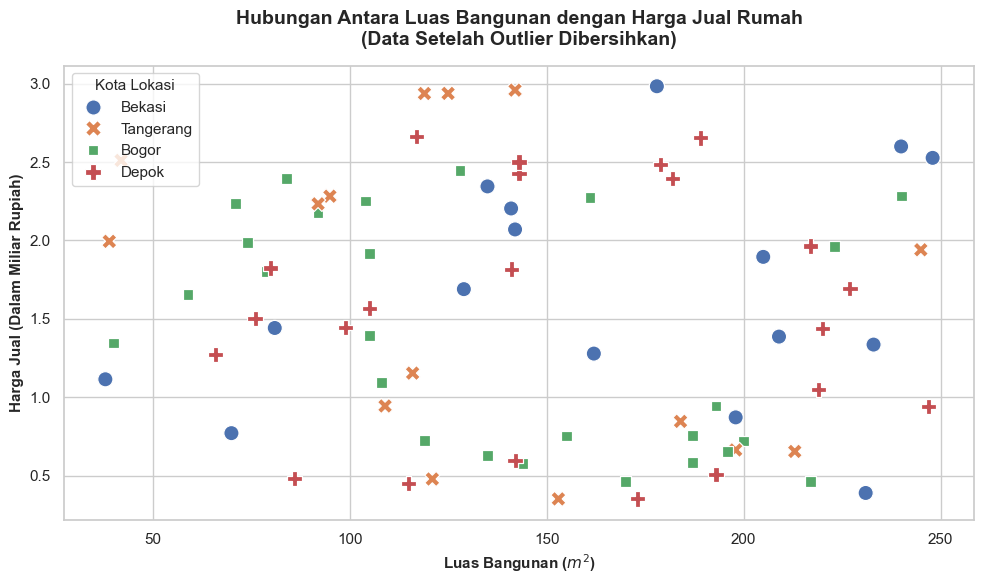

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== MEMBUAT VISUALISASI FINAL ===")

# 1. Mengatur tema visual grafik agar terlihat modern dan bersih
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Membuat Scatterplot Korelasi antara Luas Bangunan vs Harga Jual
# Membagi Harga Jual dengan 1.000.000.000 (1e9) agar sumbu Y menampilkan satuan Miliar Rupiah yang rapi
sns.scatterplot(
    data=df_clean,
    x="Luas_Bangunan_m2",
    y=df_clean["Harga_Jual_Rupiah"] / 1e9,
    hue="Kota_Lokasi",  # Membedakan warna titik berdasarkan kota
    style="Kota_Lokasi",  # Membedakan bentuk ikon titik berdasarkan kota
    s=120,  # Ukuran lingkaran data dibuat lebih besar agar jelas
    palette="deep",  # PERBAIKAN: Menggunakan huruf kecil 'deep'
)

# 3. Menambahkan Judul dan Keterangan Sumbu Grafik yang Informatif
plt.title(
    "Hubungan Antara Luas Bangunan dengan Harga Jual Rumah\n(Data Setelah Outlier Dibersihkan)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Luas Bangunan ($m^2$)", fontsize=11, fontweight="bold")
plt.ylabel("Harga Jual (Dalam Miliar Rupiah)", fontsize=11, fontweight="bold")

# 4. Merapikan posisi legenda dan tata letak komponen grafik
plt.legend(title="Kota Lokasi", title_fontsize="11", loc="upper left")
plt.tight_layout()

# 5. Menyimpan grafik otomatis ke dalam folder proyek Anda
plt.savefig("scatterplot_korelasi_final.png", dpi=300)
plt.show()
